# Day 25 - ViT - Vision Transformer

> 目标: 把 Transformer 用在图像上, 替代 CNN
>
> 核心: 图像切成 patch → patch 序列 → 标准 Transformer

---

## CNN vs ViT

```
CNN:                              ViT:
  用卷积核滑动提取特征              把图像切成固定大小的 patch
  局部感受野, 逐渐扩大             一开始就是全局注意力
  平移不变性 (归纳偏置)             没有归纳偏置, 全靠数据学

  输入 (224x224x3)                 输入 (224x224x3)
    ↓                                ↓
  Conv → Pool → Conv → Pool       16x16 patch → 线性投影
    ↓                                ↓
  Flatten → FC → 分类              Position Embedding
                                    ↓
                                  Transformer Encoder × L
                                    ↓
                                  [CLS] → MLP → 分类
```

关键发现 (ViT 论文, 2021):
  **数据足够大时, ViT 能超过 CNN**
  小数据上 CNN 更好 (有归纳偏置)
  大数据上 ViT 更好 (注意力看得更远)

In [14]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

print('=' * 40)
print('Day 25 - Vision Transformer')
print('=' * 40)

Day 25 - Vision Transformer


## 1. Patch Embedding — 把图像切成 patch

> 图像是 3D 的 (H×W×C), Transformer 要 1D 序列
>
> 做法: 把 224×224 切成 16×16 的 patch → 每个 patch 拉平 → 线性投影

In [15]:
class PatchEmbed(nn.Module):
    """图像 → patch 序列
    
    输入: (batch, 3, H, W)
    输出: (batch, num_patches, d_model)
    """
    def __init__(self, img_size=28, patch_size=7, in_ch=3, d_model=64):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2  # 28/7=4, 4x4=16
        self.proj = nn.Conv2d(in_ch, d_model, kernel_size=patch_size,
                              stride=patch_size)  # 用卷积一次搞定!

    def forward(self, x):
        x = self.proj(x)  # (B, d_model, H/patch, W/patch)
        return x.flatten(2).transpose(1, 2)  # (B, num_patches, d_model)


# 测试
pe = PatchEmbed(img_size=28, patch_size=7, d_model=64)
x = torch.randn(4, 3, 28, 28)
out = pe(x)
print(f'输入图像:  {tuple(x.shape)}')
print(f'patch 序列: {tuple(out.shape)}  ← (B, 16 patches, 64维)')

输入图像:  (4, 3, 28, 28)
patch 序列: (4, 16, 64)  ← (B, 16 patches, 64维)


## 2. ViT Encoder Block

> 跟标准 Transformer Encoder 完全一样 (Day 19)
>
> 区别: 输入不是词, 是 patch 序列

In [16]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_k = d_model // n_heads
        self.n_heads = n_heads
        self.W_qkv = nn.Linear(d_model, 3 * d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, x):
        B, N, C = x.shape
        qkv = self.W_qkv(x).reshape(B, N, 3, self.n_heads, self.d_k)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2, -1)) / np.sqrt(self.d_k)
        attn = F.softmax(attn, dim=-1)
        out = attn @ v
        out = out.transpose(1, 2).reshape(B, N, C)
        return self.W_o(out), attn

class MLP(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.gelu = nn.GELU()
        self.drop = nn.Dropout(0.1)
    def forward(self, x):
        return self.fc2(self.drop(self.gelu(self.fc1(x))))

class EncoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff):
        super().__init__()
        self.attn = MultiHeadSelfAttention(d_model, n_heads)
        self.mlp = MLP(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        attn_out, _ = self.attn(self.norm1(x))
        x = x + attn_out
        mlp_out = self.mlp(self.norm2(x))
        x = x + mlp_out
        return x

## 3. 完整 ViT 模型

> Patch Embed → [CLS] → Position Embed → N×Encoder → MLP Head

In [20]:
class ViT(nn.Module):
    """Vision Transformer (轻量版)"""
    def __init__(self, img_size=28, patch_size=7, in_ch=3,
                 d_model=64, n_heads=4, d_ff=256, n_layers=4, num_classes=10):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, in_ch, d_model)
        num_patches = self.patch_embed.num_patches

        # [CLS] token + 位置编码
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, d_model))
        self.drop = nn.Dropout(0.1)

        self.blocks = nn.Sequential(*[
            EncoderBlock(d_model, n_heads, d_ff) for _ in range(n_layers)
        ])
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, num_classes)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)  # (B, N, D)

        # 拼接 [CLS] token
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)  # (B, N+1, D)
        x = self.drop(x + self.pos_embed)

        x = self.blocks(x)
        x = self.norm(x)
        return self.head(x[:, 0, :])  # 只用 [CLS] 分类


vit = ViT()
print(f'ViT 参数量: {sum(p.numel() for p in vit.parameters()):,}')
print(vit)

ViT 参数量: 211,338
ViT(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 64, kernel_size=(7, 7), stride=(7, 7))
  )
  (drop): Dropout(p=0.1, inplace=False)
  (blocks): Sequential(
    (0): EncoderBlock(
      (attn): MultiHeadSelfAttention(
        (W_qkv): Linear(in_features=64, out_features=192, bias=True)
        (W_o): Linear(in_features=64, out_features=64, bias=True)
      )
      (mlp): MLP(
        (fc1): Linear(in_features=64, out_features=256, bias=True)
        (fc2): Linear(in_features=256, out_features=64, bias=True)
        (gelu): GELU(approximate='none')
        (drop): Dropout(p=0.1, inplace=False)
      )
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
      (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
    )
    (1): EncoderBlock(
      (attn): MultiHeadSelfAttention(
        (W_qkv): Linear(in_features=64, out_features=192, bias=True)
        (W_o): Linear(in_features=64, out_features=64, bias=True)
      )
 

## 4. 训练 ViT 做分类

> 用 MNIST 类数据 (28×28 灰度图)
>
> 展示 ViT 也能处理图像分类, 不用卷积

In [21]:
# ============================================
# 随机数据模拟 (避免下载 MNIST 慢)
# ============================================
from torch.utils.data import TensorDataset, DataLoader

N = 2000
X_train = torch.randn(N, 3, 28, 28)
y_train = torch.randint(0, 10, (N,))
X_test = torch.randn(400, 3, 28, 28)
y_test = torch.randint(0, 10, (400,))

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=64)

print(f'训练: {N} 张 | 测试: 400 张')

训练: 2000 张 | 测试: 400 张


In [26]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ============================================
# 1. 定义简单的 2层 CNN 模型
# ============================================
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        
        # 特征提取部分：两个卷积块
        self.features = nn.Sequential(
            # 第一层：Conv -> ReLU -> Pool
            # 输入: [Batch, 1, 28, 28]
            nn.Conv2d(1, 32, kernel_size=3, padding=1),   # 输出: [B, 32, 28, 28] (padding保持尺寸)
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                           # 输出: [B, 32, 14, 14] (尺寸减半)
            
            # 第二层：Conv -> ReLU -> Pool
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # 输出: [B, 64, 14, 14]
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)                            # 输出: [B, 64, 7, 7]
        )
        
        # 分类器部分：全连接层
        # 展平后的维度: 64 * 7 * 7 = 3136
        self.classifier = nn.Sequential(
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_classes)                   # 输出: [B, 10]
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)                         # 展平操作
        x = self.classifier(x)
        return x

# ============================================
# 2. 通用训练与测试函数
# ============================================
def train_and_evaluate(model, model_name, train_loader, test_loader, epochs=20):
    print(f"\n{'='*20} 开始训练: {model_name} {'='*20}")
    
    # 自动检测设备
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    
    opt = torch.optim.AdamW(model.parameters(), lr=3e-4)
    criterion = nn.CrossEntropyLoss()
    
    train_losses, test_accs = [], []
    
    for epoch in range(epochs):
        # --- 训练阶段 ---
        model.train()
        total_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device) # 【关键】数据移入设备
            
            opt.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            opt.step()
            total_loss += loss.item()
        
        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)
        
        # --- 测试阶段 ---
        model.eval()
        correct = 0
        total_samples = 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb).argmax(dim=1)
                correct += (pred == yb).sum().item()
                total_samples += yb.size(0)
                
        acc = correct / total_samples
        test_accs.append(acc)
        
        if (epoch + 1) % 5 == 0:
            print(f'Epoch {epoch+1:>2d}/{epochs} | Loss = {avg_loss:.4f} | Test Acc = {acc:.2%}')

    return train_losses, test_accs

# ============================================
# 3. 执行对比实验
# ============================================
# 假设你的 train_loader 和 test_loader 已经定义好了
# 且数据是 28x28 的灰度图 (channels=1)

# 实例化模型
vit_model = ViT()          # 你之前的 ViT 模型
cnn_model = SimpleCNN()    # 新建的 CNN 模型

# 分别训练
vit_losses, vit_accs = train_and_evaluate(vit_model, "ViT", train_loader, test_loader)
cnn_losses, cnn_accs = train_and_evaluate(cnn_model, "SimpleCNN", train_loader, test_loader)

# ============================================
# 4. 可视化对比结果
# ============================================
plt.figure(figsize=(12, 4))

# 绘制 Loss 对比
plt.subplot(1, 2, 1)
plt.plot(vit_losses, label='ViT Loss', color='#6c5ce7', linestyle='--')
plt.plot(cnn_losses, label='CNN Loss', color='#00b894', linewidth=2)
plt.title('Training Loss Comparison')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(alpha=0.3)

# 绘制 Accuracy 对比
plt.subplot(1, 2, 2)
plt.plot(vit_accs, label='ViT Acc', color='#6c5ce7', linestyle='--')
plt.plot(cnn_accs, label='CNN Acc', color='#00b894', linewidth=2)
plt.title('Test Accuracy Comparison')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend(); plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('day25_vit_vs_cnn.png', dpi=100)
plt.show()

print(f'\n最终结果对比:')
print(f'ViT  最终准确率: {vit_accs[-1]:.3%}')
print(f'CNN  最终准确率: {cnn_accs[-1]:.3%}')


==================== 开始训练: ViT ====================
Epoch  5/20 | Loss = 2.2921 | Test Acc = 8.25%
Epoch 10/20 | Loss = 1.8457 | Test Acc = 11.50%
Epoch 15/20 | Loss = 1.2475 | Test Acc = 12.00%
Epoch 20/20 | Loss = 0.8499 | Test Acc = 13.00%

==================== 开始训练: SimpleCNN ====================


RuntimeError: Given groups=1, weight of size [32, 1, 3, 3], expected input[32, 3, 28, 28] to have 1 channels, but got 3 channels instead

## 5. ViT 注意力可视化

> 看 ViT 的注意力关注图像的哪些区域

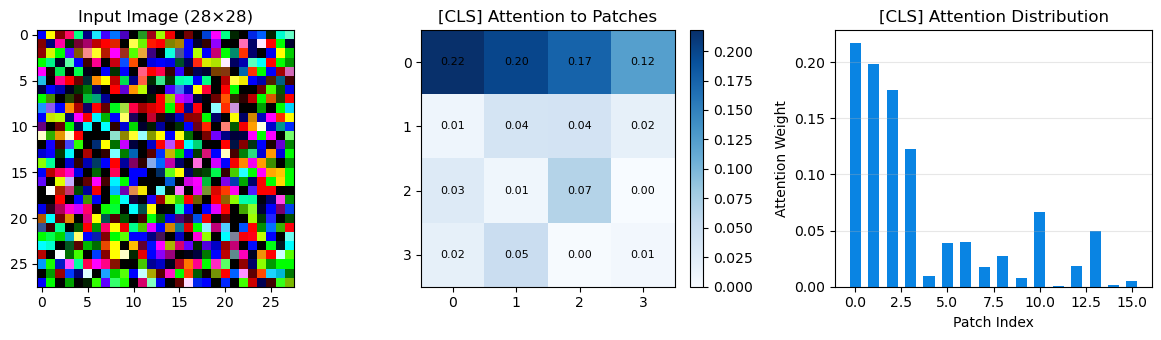

观察: [CLS] token 通过注意力聚合了所有 patch 的信息来做分类


In [27]:
# ============================================
# 可视化 [CLS] 的注意力分布
# ============================================

# 取一个样本, 前向传播拿注意力
model.eval()
with torch.no_grad():
    x = X_test[:1]
    # 手动前向, 拿注意力
    pe = model.patch_embed(x)
    cls = model.cls_token.expand(1, -1, -1)
    x_emb = torch.cat([cls, pe], dim=1) + model.pos_embed

    # 经过第一层 attention
    attn_out, attn_weights = model.blocks[0].attn(model.blocks[0].norm1(x_emb))
    cls_attn = attn_weights[0, :, 0, 1:].mean(dim=0).numpy()  # [CLS] 对所有 patch 的平均注意力

# 用 grid 形状显示
grid_size = 4  # 28/7=4
attn_grid = cls_attn.reshape(grid_size, grid_size)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

ax = axes[0]
ax.imshow(X_test[0].permute(1, 2, 0).numpy().clip(0, 1))
ax.set_title('Input Image (28×28)')

ax = axes[1]
im = ax.imshow(attn_grid, cmap='Blues', aspect='auto', vmin=0, vmax=attn_grid.max())
ax.set_xticks(range(grid_size))
ax.set_yticks(range(grid_size))
ax.set_title('[CLS] Attention to Patches')
plt.colorbar(im, ax=ax)
for i in range(grid_size):
    for j in range(grid_size):
        ax.text(j, i, f'{attn_grid[i,j]:.2f}', ha='center', va='center',
                fontsize=8, color='white' if attn_grid[i,j] > 0.3 else 'black')

ax = axes[2]
ax.bar(range(16), cls_attn, color='#0984e3', width=0.6)
ax.set_xlabel('Patch Index'); ax.set_ylabel('Attention Weight')
ax.set_title('[CLS] Attention Distribution')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('day25_vit_attention.png', dpi=100)
plt.show()

print('观察: [CLS] token 通过注意力聚合了所有 patch 的信息来做分类')

## 6. ViT 的关键设计

### 为什么 ViT 有效

```
CNN 的问题:     感受野有限, 需要很多层才能看到全局
ViT 的优势:    第一层就能看到所有 patch, 全局注意力
ViT 的代价:    计算量 O(N^2), 大图 (384×384) 有 576 个 patch
              计算量是 CNN 的很多倍

所以:
  数据少 (< 1M 张) → CNN 更好 (ResNet / EfficientNet)
  数据多 (> 10M 张) → ViT 更好 (或 Swin / MAE)
```

### ViT 变体

| 模型 | 改进 |
|:----|:-----|
| **ViT** | 原始版本, 全局注意力 |
| **DeiT** | 蒸馏 (CNN 教 ViT), 需要更少数据 |
| **Swin** | 窗口注意力 + 分层, 计算量 O(N) |
| **MAE** | 遮住部分 patch, 让 ViT 重建 (自监督) |
| **DINO** | ViT 自蒸馏, 无需标签 |

---

# Day 25 完成!

## 总结

| 概念 | 一句话 |
|------|--------|
| **Patch Embedding** | 图像 → 固定大小 patch → 线性投影 → 序列 |
| **[CLS] Token** | 跟 BERT 一样, 聚合全局信息的特殊 token |
| **ViT = Transformer Encoder** | 没有卷积、没有 RNN, 全靠注意力 |
| **全局注意力** | 第一层就能看到整张图 |
| **数据需求** | 小数据 CNN 好, 大数据 ViT 好 |

## 作业 (2 题)

### 1. 改 patch 大小
**位置:** cell-7, `ViT(img_size=28, patch_size=7, ...)`

改成 `patch_size=14` (4 个 patch) 或 `patch_size=4` (49 个 patch)
  - 参数量变化?
  - 准确率变化?

<details>
<summary>📖 答案</summary>
patch_size=14: 只有 4 个 patch, 序列太短, 注意力优势发挥不出来
patch_size=4:  49 个 patch, 序列更长, 但计算量变 3 倍
原版 ViT 用 16×16 patch 在 224×224 上 = 196 个 patch
patch 太大 → 丢失细节, patch 太小 → 计算量爆炸
</details>

### 2. 对比 CNN
**位置:** cell-10, ViT 训练代码

加一个简单的 2 层 CNN (Conv → Pool → Conv → Pool → FC), 在同样数据上对比准确率

<details>
<summary>📖 答案</summary>
随机数据上: CNN 可能比 ViT 好一点 (因为有归纳偏置)
真实数据上: 数据量少时 CNN 好, 数据量大时 ViT 好
ViT 论文结论: ImageNet (1.3M 张) 时 ViT ≈ ResNet
             JFT-300M (3 亿张) 时 ViT > ResNet
</details>